In [2]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline
import math

dir_name = 'heterogeneity_results'

# file_name_ddn = '2024-09-26_single_task_exp_DDN_fixed_decay_per_cluster.p'
# file_name_esn = '2024-09-26_single_task_exp_BL_fixed_decay_per_cluster.p'


# esn_dict = pkl.load(open(dir_name + '/' + file_name_esn, 'rb'))
# ddn_dict = pkl.load(open(dir_name + '/' + file_name_ddn, 'rb'))

file_name_esn_dist_net    = '2025-02-12_single_task_exp_BL_dist_decay_net_wide.p'
file_name_esn_fixed_net   = '2025-02-12_single_task_exp_BL_fixed_decay_net_wide.p'

file_name_ddn_fixed_net   = '2025-02-13_single_task_exp_DDN_fixed_decay_net_wide.p'
file_name_ddn_dist_net    = '2025-02-12_single_task_exp_DDN_dist_decay_net_wide.p'

 
file_name_ESN_dist_decay_net_wide                   =  '2025-02-12_single_task_exp_BL_dist_decay_net_wide.p'
file_name_ESN_fixed_decay_net_wide                  =  '2025-03-19_single_task_exp_BL_fixed_decay_net_wide.p'

file_name_DDN_dist_decay_net_wide                   =  '2025-02-12_single_task_exp_DDN_dist_decay_net_wide.p'
file_name_DDN_fixed_decay_net_wide                  =  '2025-02-12_single_task_exp_DDN_fixed_decay_net_wide.p'

file_name_DDN_dist_decay_net_wide_fixed_delays      =  '2025-02-15_single_task_exp_DDN_dist_decay_net_wide_fixed_delays.p'
file_name_DDN_dist_decay_per_cluster_fixed_delays   =  '2025-02-15_single_task_exp_DDN_dist_decay_per_cluster_fixed_delays.p'
file_name_DDN_fixed_decay_per_cluster_fixed_delays  =  '2025-02-15_single_task_exp_DDN_fixed_decay_per_cluster_fixed_delays.p'
file_name_DDN_fixed_decay_net_wide_fixed_delays     =  '2025-03-19_single_task_exp_DDN_fixed_decay_net_wide_fixed_delays.p'



# esn_dist_net_dict    =  pkl.load(open(dir_name + '/' + file_name_esn_dist_net,    'rb'))
# esn_dist_clust_dict  =  pkl.load(open(dir_name + '/' + file_name_esn_dist_clust,  'rb'))
# esn_fixed_net_dict   =  pkl.load(open(dir_name + '/' + file_name_esn_fixed_net,   'rb'))
# esn_fixed_clust_dict =  pkl.load(open(dir_name + '/' + file_name_esn_fixed_clust, 'rb'))
# ddn_fixed_net_dict   =  pkl.load(open(dir_name + '/' + file_name_ddn_fixed_net,   'rb'))
# ddn_fixed_clust_dict =  pkl.load(open(dir_name + '/' + file_name_ddn_fixed_clust, 'rb'))
# ddn_dist_net_dict    =  pkl.load(open(dir_name + '/' + file_name_ddn_dist_net,    'rb'))
# ddn_dist_clust_dict  =  pkl.load(open(dir_name + '/' + file_name_ddn_dist_clust,  'rb'))


ESN_dist_decay_net_wide_dict                  =  pkl.load(open(dir_name+'/'+ file_name_ESN_dist_decay_net_wide             		,'rb'))
ESN_fixed_decay_net_wide_dict                 =  pkl.load(open(dir_name+'/'+ file_name_ESN_fixed_decay_net_wide					,'rb'))

DDN_dist_decay_net_wide_dict                  =  pkl.load(open(dir_name+'/'+ file_name_DDN_dist_decay_net_wide					,'rb'))
DDN_fixed_decay_net_wide_dict                 =  pkl.load(open(dir_name+'/'+ file_name_DDN_fixed_decay_net_wide					,'rb'))

DDN_dist_decay_net_wide_fixed_delays_dict     =  pkl.load(open(dir_name+'/'+ file_name_DDN_dist_decay_net_wide_fixed_delays		,'rb'))
DDN_dist_decay_per_cluster_fixed_delays_dict  =  pkl.load(open(dir_name+'/'+ file_name_DDN_dist_decay_per_cluster_fixed_delays	,'rb'))
DDN_fixed_decay_per_cluster_fixed_delays_dict =  pkl.load(open(dir_name+'/'+ file_name_DDN_fixed_decay_per_cluster_fixed_delays	,'rb'))
DDN_fixed_decay_net_wide_fixed_delays_dict    =  pkl.load(open(dir_name+'/'+ file_name_DDN_fixed_decay_net_wide_fixed_delays	,'rb'))



from tensorflow.python.ops import parallel_for as pfor

import pdb

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
# import tf_utils
def reset_graph():
    if 'sess' in globals() and sess:
        sess.close()
    tf.compat.v1.reset_default_graph() 

def plot_fps(
	state_traj=None,
	plot_batch_idx=None,
	plot_start_time=0,
	plot_stop_time=None,
	mode_scale=0.25,
	fig=None,
	is_lif=False,
	cust_idx = None,
	cust_col = 'g',
	plot_points = True,
	plot_custom = False):

	'''Plots a visualization and analysis of the unique fixed points.

	1) Finds a low-dimensional subspace for visualization via PCA. If
	state_traj is provided, PCA is fit to [all of] those RNN state
	trajectories. Otherwise, PCA is fit to the identified unique fixed
	points. This subspace is 3-dimensional if the RNN state dimensionality
	is >= 3.

	2) Plots the PCA representation of the stable unique fixed points as
	black dots.

	3) Plots the PCA representation of the unstable unique fixed points as
	red dots.

	4) Plots the PCA representation of the modes of the Jacobian at each
	fixed point. By default, only unstable modes are plotted.

	5) (optional) Plots example RNN state trajectories as blue lines.

	Args:
		fps: a FixedPoints object. See FixedPoints.py.

		state_traj (optional): [n_batch x n_time x n_states] numpy
		array or LSTMStateTuple with .c and .h as
		[n_batch x n_time x n_states/2] numpy arrays. Contains example
		trials of RNN state trajectories.

		plot_batch_idx (optional): Indices specifying which trials in
		state_traj to plot on top of the fixed points. Default: plot all
		trials.

		plot_start_time (optional): int specifying the first timestep to
		plot in the example trials of state_traj. Default: 0.

		plot_stop_time (optional): int specifying the last timestep to
		plot in the example trials of stat_traj. Default: n_time.

		stop_time (optional):

		mode_scale (optional): Non-negative float specifying the scaling
		of the plotted eigenmodes. A value of 1.0 results in each mode
		plotted as a set of diametrically opposed line segments
		originating at a fixed point, with each segment's length specified
		by the magnitude of the corresponding eigenvalue.

		fig (optional): Matplotlib figure upon which to plot.

	Returns:
		None.
	'''

	FONT_WEIGHT = 'bold'
	if fig is None:
		FIG_WIDTH = 8 # inches
		FIG_HEIGHT = 8 # inches
		fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT),
			tight_layout=True)

	if state_traj is not None:
		if tf_utils.is_lstm(state_traj):
			state_traj_bxtxd = tf_utils.convert_from_LSTMStateTuple(
		state_traj)
		else:
			state_traj_bxtxd = state_traj

		[n_batch, n_time, n_states] = state_traj_bxtxd.shape

		# Ensure plot_start_time >= 0
		plot_start_time = np.max([plot_start_time, 0])

		if plot_stop_time is None:
			plot_stop_time = n_time
		else:
			# Ensure plot_stop_time <= n_time
			plot_stop_time = np.min([plot_stop_time, n_time])

		plot_time_idx = range(plot_start_time, plot_stop_time)

	
	n_states = n_states

	if n_states >= 3:
		pca = PCA(n_components=3)

		if state_traj is not None:
			state_traj_btxd = np.reshape(state_traj_bxtxd,
				(n_batch*n_time, n_states))
			pca.fit(state_traj_btxd)


		ax = fig.add_subplot(111, projection='3d')
		# ax = Axes3D(fig)

		ax.set_xlabel('PC 1', fontweight=FONT_WEIGHT)
		ax.set_zlabel('PC 3', fontweight=FONT_WEIGHT)
		ax.set_ylabel('PC 2', fontweight=FONT_WEIGHT)

		# For generating figure in paper.md
		ax.set_xticks([-2, -1, 0, 1, 2])
		ax.set_yticks([-1, 0, 1])
		ax.set_zticks([-1, 0, 1])
	else:
		# For 1D or 0D networks (i.e., never)
		pca = None
		ax = fig.add_subplot(111)
		ax.xlabel('Hidden 1', fontweight=FONT_WEIGHT)
		if n_states == 2:
			ax.ylabel('Hidden 2', fontweight=FONT_WEIGHT)

	if state_traj is not None:
		if plot_batch_idx is None:
			plot_batch_idx = range(n_batch)

		for batch_idx in plot_batch_idx:
			x_idx = state_traj_bxtxd[batch_idx]

			if n_states >= 3:
				z_idx = pca.transform(x_idx[plot_time_idx, :])
			else:
				z_idx = x_idx[plot_time_idx, :]
			plot_123d(ax, z_idx, color='r', linewidth=0.2)
	


	# for angle in range(0, 360):
	# 	ax.view_init(30, angle)
	# 	plt.draw()
	# 	plt.pause(.001)
	# 	# plt.show()
	plt.ion()
	plt.show()
	plt.pause(1e-10)

def plot_123d(ax, z, **kwargs):
	'''Plots in 1D, 2D, or 3D.

	Args:
		ax: Matplotlib figure axis on which to plot everything.

		z: [n x n_states] numpy array containing data to be plotted,
		where n_states is 1, 2, or 3.

		any keyword arguments that can be passed to ax.plot(...).

	Returns:
		None.
	'''
	n_states = z.shape[1]
	
	if n_states ==3:
		ax.plot(z[:, 0], z[:, 1], z[:, 2], **kwargs)
	elif n_states == 2:
		ax.plot(z[:, 0], z[:, 1], **kwargs)
	elif n_states == 1:
		ax.plot(z, **kwargs)
	return ax

In [3]:
import sys
sys.path.append('C:/Users/Nishant Joshi/Downloads/DDN-public/fixed-point-finder')

In [4]:
sys.path.append('TF_version')
from ESN_cell import * 

In [5]:
# esn_example = esn_dict['example net']
# ddn_example = ddn_dict['example net']




ESN_dist_decay_net_wide_example                   = ESN_dist_decay_net_wide_dict['example net'] 
ESN_fixed_decay_net_wide_example                  = ESN_fixed_decay_net_wide_dict['example net'] 

DDN_dist_decay_net_wide_example                   = DDN_dist_decay_net_wide_dict['example net'] 
DDN_fixed_decay_net_wide_example                  = DDN_fixed_decay_net_wide_dict['example net'] 

DDN_dist_decay_net_wide_fixed_delays_example      = DDN_dist_decay_net_wide_fixed_delays_dict['example net'] 
DDN_dist_decay_per_cluster_fixed_delays_example   = DDN_dist_decay_per_cluster_fixed_delays_dict['example net'] 
DDN_fixed_decay_per_cluster_fixed_delays_example  = DDN_fixed_decay_per_cluster_fixed_delays_dict['example net'] 
DDN_fixed_decay_net_wide_fixed_delays_example     = DDN_fixed_decay_net_wide_fixed_delays_dict['example net']

In [6]:
def get_validation_throughout_evolution(dict, gen_max, populations=False, multitask=False):
    """_summary_

    Args:
        dict (_type_): _description_
        gen_max (_type_): _description_
        populations (bool, optional): _description_. Defaults to False.
        multitask (bool, optional): _description_. Defaults to False.

    Returns:
        _type_: _description_
    """
    # Validation scores are saved in a matrix with dimensions:
    # generations x hyperparameter candidates x re-initializations x lag search grid
    if not multitask:
        all_scores = dict['validation performance'][:gen_max, :, :, :]
    else:
        all_scores = dict['validation performance'][:gen_max, :, :, :, :]
    # from the lag search grid we select the best score (lowest NRMSE), since this was the best 
    # performing readout model
    best_lag_scores = np.min(all_scores, axis=-1)
    
    if multitask:
        # from the tasks, we select the average
        # best_lag_scores = best_lag_scores[:, :, :, 0]**2
        best_lag_scores = np.mean(best_lag_scores, axis=-1)
    
    # from the re-initializations from the same hyperparameter set/candidate, we take the average
    best_candidate_scores = np.mean(best_lag_scores, axis=-1)
    
    if populations:
        return best_candidate_scores
    
    # from the population of hyperparameter candidates, we select the best candidate
    best_gen_scores = np.min(best_candidate_scores, axis=-1)
    return best_gen_scores

def get_best_candidate(dict, gen_max, multitask=False):
    """_summary_

    Args:
        dict (_type_): _description_
        gen_max (_type_): _description_
        multitask (bool, optional): _description_. Defaults to False.

    Returns:
        _type_: _description_
    """
    best_gen_scores = get_validation_throughout_evolution(dict, gen_max, multitask=multitask)   
    best_candidates = get_validation_throughout_evolution(dict, gen_max, populations=True, multitask=multitask)
    best_gen_ind = np.argmin(best_gen_scores)
    best_candidate_ind = np.argmin(best_candidates[best_gen_ind])
    return best_gen_ind, best_candidate_ind
    
def sample_best_net(dict, n, gen_max, multitask=False):
    """_summary_

    Args:
        dict (_type_): _description_
        n (_type_): _description_
        gen_max (_type_): _description_
        multitask (bool, optional): _description_. Defaults to False.

    Returns:
        _type_: _description_
    """
    gen, ind = get_best_candidate(dict, gen_max, multitask=multitask)
    print(gen, ind)
    start_net = dict['example net']
    best_parameter_set = dict['parameters'][gen, ind, :]
    best_nets = []
    for i in range(n):
        best_net = start_net.get_new_network_from_serialized(best_parameter_set)
        best_nets.append(best_net)
    return best_nets


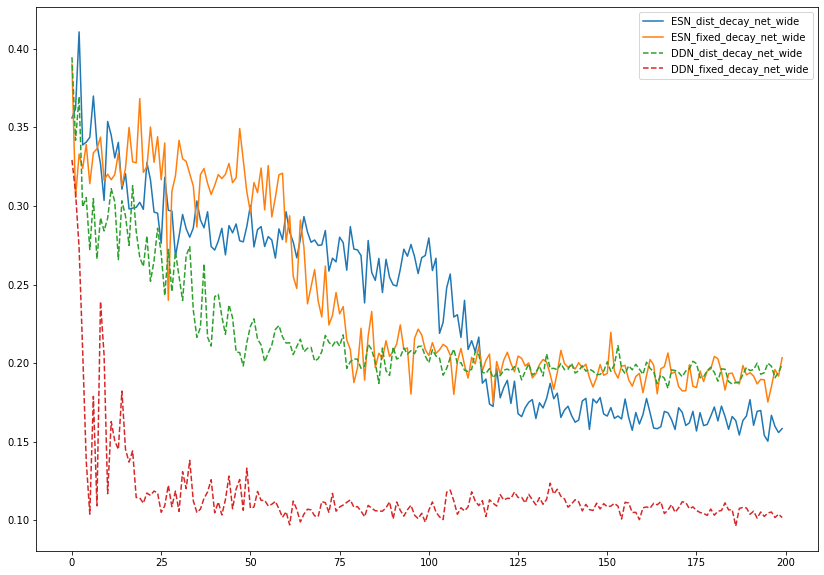

In [7]:

gen_max = 220
# val_scores_ddn = get_validation_throughout_evolution(ddn_dict, gen_max, multitask=False)
# val_scores_esn = get_validation_throughout_evolution(esn_dict, gen_max, multitask=False)

val_score_ESN_dist_decay_net_wide_dict                 =  get_validation_throughout_evolution(ESN_dist_decay_net_wide_dict, gen_max=gen_max, multitask=False)
val_score_ESN_fixed_decay_net_wide_dict                =  get_validation_throughout_evolution(ESN_fixed_decay_net_wide_dict, gen_max=gen_max, multitask=False)
val_score_DDN_dist_decay_net_wide_dict                 =  get_validation_throughout_evolution(DDN_dist_decay_net_wide_dict, gen_max=gen_max, multitask=False)
val_score_DDN_fixed_decay_net_wide_dict                =  get_validation_throughout_evolution(DDN_fixed_decay_net_wide_dict, gen_max=gen_max, multitask=False)

# val_score_DDN_dist_decay_net_wide_fixed_delays_dict    =  get_validation_throughout_evolution(DDN_dist_decay_net_wide_fixed_delays_dict, gen_max=gen_max, multitask=False)
# val_score_DDN_dist_decay_per_cluster_fixed_delays_dict =  get_validation_throughout_evolution(DDN_dist_decay_per_cluster_fixed_delays_dict, gen_max=gen_max, multitask=False)
# val_score_DDN_fixed_decay_per_cluster_fixed_delays_dict=  get_validation_throughout_evolution(DDN_fixed_decay_per_cluster_fixed_delays_dict, gen_max=gen_max, multitask=False)
# val_score_DDN_fixed_decay_net_wide_fixed_delays_dict   =  get_validation_throughout_evolution(DDN_fixed_decay_net_wide_fixed_delays_dict, gen_max=gen_max, multitask=False)

fig = plt.figure(figsize= [14,10])

plt.plot(val_score_ESN_dist_decay_net_wide_dict,                   linestyle='-',  label ='ESN_dist_decay_net_wide' )
plt.plot(val_score_ESN_fixed_decay_net_wide_dict,                  linestyle='-',  label ='ESN_fixed_decay_net_wide' )
plt.plot(val_score_DDN_dist_decay_net_wide_dict,                   linestyle='--', label ='DDN_dist_decay_net_wide' )
plt.plot(val_score_DDN_fixed_decay_net_wide_dict,                  linestyle='--', label ='DDN_fixed_decay_net_wide' )

# plt.plot(val_score_DDN_dist_decay_net_wide_fixed_delays_dict,      linestyle=':',  label ='val_score_DDN_dist_decay_net_wide_fixed_delays_dict' )
# plt.plot(val_score_DDN_dist_decay_per_cluster_fixed_delays_dict,   linestyle=':',  label ='val_score_DDN_dist_decay_per_cluster_fixed_delays_dict' )
# plt.plot(val_score_DDN_fixed_decay_per_cluster_fixed_delays_dict,  linestyle=':',  label ='val_score_DDN_fixed_decay_per_cluster_fixed_delays_dict' )
# plt.plot(val_score_DDN_fixed_decay_net_wide_fixed_delays_dict,     linestyle=':',  label ='val_score_DDN_fixed_decay_net_wide_fixed_delays_dict' )

plt.legend()

# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/NARMA_val_scores.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
print(np.min(val_score_ESN_dist_decay_net_wide_dict))
print(np.min(val_score_ESN_fixed_decay_net_wide_dict))

print(np.min(val_score_DDN_dist_decay_net_wide_dict))
print(np.min(val_score_DDN_fixed_decay_net_wide_dict))


0.15035312205223214
0.17459573615097929
0.18395249195930455
0.09635947296137579


In [9]:
nr_of_nets = 10
gen_max = 180

best_nets_ESN_dist_decay_net_wide_dict                   = sample_best_net(ESN_dist_decay_net_wide_dict,                  nr_of_nets, gen_max, multitask=False)
best_nets_ESN_fixed_decay_net_wide_dict                  = sample_best_net(ESN_fixed_decay_net_wide_dict,                 nr_of_nets, gen_max, multitask=False)
best_nets_DDN_dist_decay_net_wide_dict                   = sample_best_net(DDN_dist_decay_net_wide_dict,                  nr_of_nets, gen_max, multitask=False)
best_nets_DDN_fixed_decay_net_wide_dict                  = sample_best_net(DDN_fixed_decay_net_wide_dict,                 nr_of_nets, gen_max, multitask=False)

best_nets_DDN_dist_decay_net_wide_fixed_delays_dict      = sample_best_net(DDN_dist_decay_net_wide_fixed_delays_dict,     nr_of_nets, gen_max, multitask=False)
best_nets_DDN_dist_decay_per_cluster_fixed_delays_dict   = sample_best_net(DDN_dist_decay_per_cluster_fixed_delays_dict,  nr_of_nets, gen_max, multitask=False)
best_nets_DDN_fixed_decay_per_cluster_fixed_delays_dict  = sample_best_net(DDN_fixed_decay_per_cluster_fixed_delays_dict, nr_of_nets, gen_max, multitask=False)
best_nets_DDN_fixed_decay_net_wide_fixed_delays_dict     = sample_best_net(DDN_fixed_decay_net_wide_fixed_delays_dict,    nr_of_nets, gen_max, multitask=False)

175 8
118 7
167 9
61 24
144 5
38 19
74 3
178 9


# Memory Capacity

In [10]:
import numpy as np
from simulator import NetworkSimulator
import capacities as CAP
import matplotlib.pyplot as plt
import seaborn as sns
from visual_example import get_example_networks
from reservoirpy.datasets import mackey_glass
from sklearn.linear_model import Ridge, RidgeCV
from utils import autocorrelation
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))


## Linear Memory Capacity

In [11]:
best_nets_ESN_dist_decay_net_wide_dict

In [17]:
# from utils import memory_capacity


def memory_capacity(network, max_delay, sequence_length, z_function=None, warmup_time=400, alphas=[1, 10, 100]):
    noise_input_train = np.random.uniform(-1,1,size=sequence_length + warmup_time)
    z_output_train = np.copy(noise_input_train)
    if z_function is not None:
        z_output_train = z_function(noise_input_train)

    # Training
    sim = NetworkSimulator(network)
    train_net_act = sim.get_network_data(noise_input_train)

    readout_list = []
    for d in range(max_delay):
        readout = RidgeCV(alphas=alphas, cv=5)
        readout.fit(train_net_act[:, warmup_time:].T, z_output_train[warmup_time-d:len(z_output_train)-d])
        readout_list.append(readout)

    # Testing
    sim.reset()
    noise_input_test = np.random.uniform(-1,1,size=sequence_length + warmup_time)
    z_output_test = np.copy(noise_input_test)
    if z_function is not None:
        z_output_test = z_function(noise_input_test)

    test_net_act = sim.get_network_data(noise_input_test)

    m_caps = []

    for d, readout in enumerate(readout_list):
        predictions = readout.predict(test_net_act[:, warmup_time:].T)
        MC = np.corrcoef(predictions, z_output_test[warmup_time-d:len(z_output_test)-d])[0,1]
        m_caps.append(MC)

    return m_caps

caps = []

nets= [best_nets_ESN_dist_decay_net_wide_dict[0],
       best_nets_ESN_fixed_decay_net_wide_dict[0],
       best_nets_DDN_dist_decay_net_wide_dict[0],
       best_nets_DDN_fixed_decay_net_wide_dict[0],
    #    best_nets_DDN_dist_decay_net_wide_fixed_delays_dict[0],
    #    best_nets_DDN_dist_decay_per_cluster_fixed_delays_dict[0],
    #    best_nets_DDN_fixed_decay_per_cluster_fixed_delays_dict[0],
    #    best_nets_DDN_fixed_decay_net_wide_fixed_delays_dict[0],
       ]
for net  in nets :
    caps.append(memory_capacity(net, max_delay=40, sequence_length=500,))

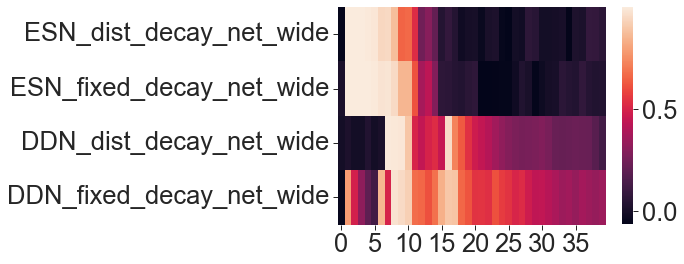

In [27]:
sns.heatmap(np.array(caps[:8]),yticklabels=['ESN_dist_decay_net_wide',
                                        'ESN_fixed_decay_net_wide',
                                        'DDN_dist_decay_net_wide',
                                        'DDN_fixed_decay_net_wide',
                                        ])
                                        # 'DDN_dist_decay_net_wide_fixed_delays',
                                        # 'DDN_dist_decay_per_cluster_fixed_delays',
                                        # 'DDN_fixed_decay_per_cluster_fixed_delays',
                                        # 'DDN_fixed_decay_net_wide_fixed_delays'],)
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/Linear_MC_NARMA_memory_capacity.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Dynamics

In [19]:
def paste_best_vars_on_nets(net):
    # reset_graph()

    vars_to_copy = ['W',
                    'WBias',
                    'n_type',
                    'coordinates',
                    'decay',
                    'neurons_in',
                    'neurons_out',
                    'activation_func',
                    'dt',
                    'theta_window',
                    'theta_y0',
                    'lr',
                    'var_delays',]

    trial_ESN = ESNCell_S(weights =vars(net)['W'] ,
                      bias =vars(net)['WBias'] ,
                      n_type =vars(net)['n_type'], 
                      coordinates =vars(net)['coordinates'], 
                      decay =vars(net)['decay'] ,
                      input_n =vars(net)['neurons_in'], 
                      output_n =vars(net)['neurons_out'], 
                      activation_func =vars(net)['activation_func'], 
                      dt =vars(net)['dt'] ,
                      theta_window =vars(net)['theta_window'] ,
                      theta_y0 =vars(net)['theta_y0'] ,
                      lr =vars(net)['lr'] ,
                      var_delays =vars(net)['var_delays'] )    
    return trial_ESN


## Luyapnov Stuff 

ESN and Chaos https://lizier.me/joseph/publications/2010-Boedecker-InfoProcessingEchoStateNets.pdf 

How to calcualte Luyapnov Spectra https://fy.chalmers.se/~f99krgu/dynsys/DynSysLecture10.pdf#page=1.11

https://arxiv.org/pdf/2006.02427#page=17.26 Important Luyapnov results

![image.png](attachment:image.png)

https://www.sciencedirect.com/science/article/pii/S0370157319302601#sec2 How to calculate jacobian of a delay differential equation 

In [20]:
from tqdm  import tqdm 
from tensorflow.python.ops.parallel_for.gradients import jacobian

def oneStepVarQR(J, Q):
    Z = tf.compat.v1.matmul(J, Q)
    q, r = tf.linalg.qr(Z, full_matrices=False)
    s = tf.linalg.diag(tf.sign(tf.linalg.diag_part(r)))
    return tf.compat.v1.matmul(q, s), tf.linalg.diag_part(tf.matmul(s, r))
# @tf.function
def calc_jac(*params, model):
	if len(params)>2:
		inputs, states, sess = params #inputs should be a single time step with batch_size entries

	else:
		inputs, states = params #inputs should be a single time step with batch_size entries

	L = model.cell.neurons_out.shape[0]

    #Feed forward into network
	N, delay = states.shape 

	with tf.GradientTape() as tape:
		model_out, F =  model.cell.call(inputs, states)
		J_tf = tape.jacobian(F[:,0], states)

	return tf.reshape(J_tf,(N,N*delay))[:N-1,:(N-1)*delay]
# @tf.function
def build_vars( init_states ):
	n_state,n_delay = init_states.shape
	init_states = np.concatenate([init_states,np.zeros((1,n_delay))],axis=0)
	x = tf.Variable(init_states,dtype=tf.float32)
	x_rnn_cell = x

	return x,x_rnn_cell

def calc_LEs_an(*params, model, k_LE=100000, rec_layer= 0, kappa = 10, diff= 10, warmup = 10, T_ons = 1):
	if len(params)>2:
		x_in = params[0]
		hc = params[1]
		sess = params[2]
	else:
		x_in = params[0]
		hc = params[1]

	h0,_ = build_vars(hc)
	hidden_size, delay = h0.shape
	input_size , feed_seq = x_in.shape
	L = model.cell.neurons_out.shape[0] #*delay
		
	k_LE = max(min(L, k_LE), 1)
	Q = tf.reshape(tf.eye(L*delay), (L, L*delay))
	Q = Q[ :, :k_LE*delay] #Choose how many exponents to track

	ht = h0    
	
	
	rvals = [] #tf.Variable(tf.ones((feed_seq, k_LE)))#storage
	qvect = [] #tf.Variable(tf.zeros((feed_seq, L, k_LE)) )#storage
	Js    = [] #tf.Variable(tf.zeros((feed_seq, L+1, L+1, delay)) )#storage
	t = 0
	J_first = None
	#Warmup
	for xt in x_in[0,:warmup]:

		states = ht
		
		J = calc_jac(tf.cast(np.array([xt]), dtype = 'float32'), states, sess, model=model)
		_, states = model.cell.call(tf.cast(np.array([xt]),dtype = 'float32'), states)

		ht = states
		Q = tf.matmul(J, Q)
	Q, _ = tf.compat.v1.qr(Q)
	#     print(Q.shape)
	
	# T_pred = np.log(kappa/diff)
	# T_ons = max(1, math.floor(T_pred))
	# print('Pred = {}, QR Interval: {}'.format(T_pred, T_ons))

	hts  = []
	t_QR = t
	for xt in x_in[0,warmup:]:
		if (t - t_QR) >= T_ons or t==0 or t == feed_seq:
			QR = True
		else: 
			QR = True

		states = ht
		

		J = calc_jac(tf.cast(np.array([xt]),dtype = 'float32'), states, sess, model=model)

		if t == 0:
			J_first = J

		_, states = model.cell.call(tf.cast(np.array([xt]),dtype = 'float32'), states) #run one step 
		
		if QR:
			Q, r = oneStepVarQR(J, Q)
			t_QR = t
			
		else:
			Q = tf.matmul(J, Q)
			r = tf.ones((1, hidden_size*delay))

		ht = states
		
		# rvals = tf.compat.v1.assign(rvals[t, :, ], r)
		# qvect = tf.compat.v1.assign(qvect[t, :, :] , Q)
		# Js    = tf.compat.v1.assign(Js[t, :, :, :] , J)

		rvals.append(r)
		qvect.append(Q)
		Js.append(J)
		hts.append(ht)
		t = t+1

		
	LEs = tf.reduce_sum(tf.experimental.numpy.log(rvals), axis = 0)/feed_seq
	
	#     print(torch.log2(rvals.detach()).shape)
	return LEs, rvals , qvect, Js, hts, J_first

def plot_evolution(rvals, k_LE, model_name = '', sample_id = 0, title = False, plot_size = (10, 7)):
    plt.figure(figsize = plot_size)
    feed_seq = rvals.shape[1]
    if type(k_LE == int):
        for i in range(k_LE):
            f = plt.plot(np.divide(np.cumsum(np.log2(rvals[i,:]),),np.arange(1., feed_seq+1)))
    else:
        f = plt.plot(np.divide(np.cumsum(np.log2(rvals[i,:]),),np.arange(1., feed_seq+1)))
    f = plt.xlabel('Iteration #')
    f = plt.ylabel('Lyapunov Exponent')
    if title:
        plt.title('LE Spectrum Evolution for '+model_name+', Sample #'+ str(sample_id))
    return f

## Find Fixed Points

In [21]:
def renormalize(gamma_0, state1, state2, norm_order = 2, count = 0):
    diff = state2- state1
    state2 = tf.cond(tf.less_equal(tf.linalg.norm(tf.linalg.norm(diff)), 0.0), 
                     lambda: tf.compat.v1.assign(state2[:,0], state1[:,0]+ gamma_0*(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64)/tf.linalg.norm(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64)))), 
                     lambda: tf.compat.v1.assign(state2[:,0], state1[:,0]+ gamma_0*(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64)/tf.linalg.norm(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64))))
                    )
                    #  lambda: tf.compat.v1.assign(state2[:,0], state1[:,0]+ gamma_0*(tf.ones_like(state2[:,0])/tf.linalg.norm(tf.ones_like(state2[:,0])))))

    return [state1, state2] 

def perturb_net(esn_model1, esn_model2, x=None, n_idx=None, pert=None):

    init_state = esn_model1.cell.A_init
    init_state_delta = esn_model1.cell.A_init.copy() 

    if i is not None:
        init_state_delta[n_idx,0] += pert*(np.ones(*init_state_delta[n_idx,0].shape)/np.linalg.norm(np.ones(*init_state_delta[n_idx,0].shape)))
    
    else:
        init_state_delta[:,0] += pert*(np.ones(*init_state_delta[:,0].shape)/np.linalg.norm(np.ones(*init_state_delta[:,0].shape)))

    state1 = init_state
    state2 = init_state_delta

    esn_model1.cell.A_init = state1
    esn_model2.cell.A_init = state2

    esn_model1.cell.build(inputs_shape = x.shape[0])
    esn_model2.cell.build(inputs_shape = x.shape[0])
    return esn_model1, esn_model2

def perturb_net_tf(state1, state2, pert=None, n_idx=None):
    if n_idx is not None:
        state2 =  tf.compat.v1.assign(state2[n_idx,0],state1[n_idx,0]+pert*(tf.ones(tf.shape(state1[n_idx,0]),dtype=tf.float64))/tf.linalg.norm(tf.ones(tf.shape(state1[n_idx,0]),dtype=tf.float64)))
    
    else:
        state2 =  tf.compat.v1.assign(state2[:,0],state1[:,0]+pert*(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64))/tf.linalg.norm(tf.ones(tf.shape(state1[:,0]),dtype=tf.float64)))

    return state1, state2

@tf.function
def lyapunov_exponents(model1, model2, input, every_k = 1, ord =2,trans=15,pert=1e-5, threshold_prec = 1e-9, N=10):

    state1 = model1.cell.A
    state2 = model2.cell.A
    rand_idx = np.random.choice(state1.shape[0], N, replace=False)
    idx = 30
    # traj_ref_rand_idx  = [] 
    # traj_pert_rand_idx = [] 
    # exps_rand_idx      = []
    # diff_k_rand_idx    = []

    # for idx in rand_idx:

    traj_ref = [] 
    traj_pert = [] 
    exps = []
    norm_diff = []
    diff_k = []
    

    traj_ref.append(state1)
    traj_pert.append(state2)
    gamma0 = tf.linalg.norm(state1[:,0] - state2[:,0])
    diff_k.append(gamma0)
    t_pert = trans+1


    for i in range(input.shape[1]):
        
        state1,_ = model1.cell.call(input[:,i], state1)
        state2,_ = model2.cell.call(input[:,i], state2)
        dist = state1[:,0] - state2[:,0]        

        if i>=t_pert:
            # Check if distance is within bounds
            if i==t_pert:
                state1,state2 = perturb_net_tf(state1,state2,pert,n_idx=idx)
                # state1,state2 = model1.cell.A,model2.cell.A
                gamma0 = tf.linalg.norm(state1[:,0] - state2[:,0])
                d_lower = 1e-14
                d_upper =  1e5 

            response  = tf.cond((tf.greater(tf.linalg.norm(dist), d_upper) or tf.less_equal(tf.linalg.norm(dist), d_lower)), lambda: renormalize(gamma0, state1, state2, norm_order=ord,count=i), lambda: [state1, state2])
            # state1  = tf.compat.v1.assign(state1,response[0])
            state2  = tf.compat.v1.assign(state2,response[1])
            if len(response)>2:
                norm_diff.append(response[2])
            dist = state1 - state2
            diff_k.append(tf.linalg.norm(dist))
            # # Calculate Lyapunov exponent
            if i%every_k==0:
                exps.append((1/every_k)*tf.math.log(tf.linalg.norm(dist) / gamma0))

            # Renormalize states
            # state1, state2  = renormalize(traj_ref[0] - traj_pert[0], state2, state1, norm_order=ord)
        else:
            diff_k.append(tf.linalg.norm(dist)) 


        traj_ref.append(tf.identity(state1))
        traj_pert.append(tf.identity(state2))



        # traj_ref_rand_idx.append(traj_ref)
        # traj_pert_rand_idx.append(traj_pert)
        # exps_rand_idx.append(exps)
        # diff_k_rand_idx.append(diff_k)

    # exp = [tf.math.log(tf.linalg.norm(j-i, ord=ord)/gamma0) for i,j in zip(traj_ref , traj_pert)]
    # diff = [tf.reduce_mean(i-j) for i,j in zip(traj_ref , traj_pert)]


    # return exps_rand_idx , diff_k_rand_idx, traj_ref_rand_idx, traj_pert_rand_idx ,gamma0
    return exps , diff_k, traj_ref, traj_pert ,gamma0

@tf.function
def lyapunov_exponents_test(model1, model2, input, every_k = 1, ord =2,trans=15,pert=1e-5, threshold_prec = 1e-9, N=10):

    state1 = model1.cell.A
    state2 = model2.cell.A

    traj_ref = [] 
    traj_pert = [] 

    traj_ref.append(state1)
    traj_pert.append(state2)
    exps = []
    gamma0 = tf.linalg.norm(state1[:,0] - state2[:,0])

    norm_diff = []
    diff_k = []
    diff_k.append(gamma0)
    t_pert = trans+1
    for i in range(input.shape[1]):
        state1,_ = model1.cell.call(input[:,i], state1)
        state2,_ = model2.cell.call(input[:,i], state2)

        dist = state1[:,0] - state2[:,0]        
        if i>=t_pert:
            # Check if distance is within bounds
            if i==t_pert:
                state1,state2 = perturb_net_tf(state1,state2,pert)
                # state1,state2 = model1.cell.A,model2.cell.A
                gamma0 = tf.linalg.norm(state1[:,0] - state2[:,0])
                d_lower = 1e-14
                d_upper =  1e5 

            # Renormalize states
            response  = tf.cond((tf.greater(tf.linalg.norm(dist), d_upper) or tf.less_equal(tf.linalg.norm(dist), d_lower)), lambda: renormalize(gamma0, state1, state2, norm_order=ord,count=i), lambda: [state1, state2])
            # state1  = tf.compat.v1.assign(state1,response[0])
            state2  = tf.compat.v1.assign(state2,response[1])
            if len(response)>2:
                norm_diff.append(response[2])
            dist = state1 - state2
            diff_k.append(tf.linalg.norm(dist))
            
            # Calculate Lyapunov exponent
            if i%every_k==0:
                exps.append((1/every_k)*tf.math.log(tf.linalg.norm(dist) / gamma0))
        else:
            diff_k.append(tf.linalg.norm(dist)) 

        traj_ref.append(tf.identity(state1))
        traj_pert.append(tf.identity(state2))

    # exp = [tf.math.log(tf.linalg.norm(j-i, ord=ord)/gamma0) for i,j in zip(traj_ref , traj_pert)]
    # diff = [tf.reduce_mean(i-j) for i,j in zip(traj_ref , traj_pert)]
    return tf.stack(traj_ref,axis=1), tf.stack(traj_pert,axis=1)


In [22]:
from FixedPointSearch_leaky import * 
from FixedPointStore_leaky import * 
from tensorflow.python.ops.parallel_for.gradients import jacobian

def run_net_on_input(net,input_size):
        net_tf = paste_best_vars_on_nets(net)
        net_tf.activation_func = sigmoid_activation_tf
        tf.compat.v1.disable_eager_execution()
        narma_input,narma_output = createNARMA30(input_size)
        INPUT = narma_input.T
        INPUT[:,:] = INPUT[:,:]
        with  tf.compat.v1.Session() as sess:
                x = tf.compat.v1.placeholder(tf.float64, [1, input_size], name='input_placeholder',)
                esn_model_ddns_fixed_net_dict = Model(cell = net_tf,   input_data = x)
                net_out,net_states = esn_model_ddns_fixed_net_dict.get_network_data_updated(x)
                sess.run(tf.compat.v1.global_variables_initializer())
                out, states = sess.run([net_out , net_states],  feed_dict = {x:INPUT})
        return out, states

def return_lyapunov_exp(net,input_size,pert=1e-9):
        net_tf_1 = paste_best_vars_on_nets(net) 
        net_tf_2 = paste_best_vars_on_nets(net) 
        net_tf_1.activation_func = sigmoid_activation_tf
        net_tf_2.activation_func = sigmoid_activation_tf

        tf.compat.v1.disable_eager_execution()
        

        # INPUT = np.random.normal(0, 0.5, size=(1,input_size))*100
        narma_input,narma_output = createNARMA30(input_size)
        INPUT = narma_input.T
        # INPUT[:,:] = INPUT[:,:]

        max_exps_esns_dist_clust, diff_esns_dist_clust ,ref_trajs_esns_dist_clust, pert_trajs_esns_dist_clust  =   [], [], [], []


        # for pert in [1e-7]: 
        threshold = pert*1e-2

        reset_graph()
        with  tf.compat.v1.Session() as sess:
                x = tf.compat.v1.placeholder(tf.float64, [1, input_size], name='input_placeholder',)

                esn_model_ddns_fixed_net_dict1 = Model(cell = net_tf_1,   input_data = x)
                esn_model_ddns_fixed_net_dict2 = Model(cell = net_tf_2,   input_data = x)
                exp_ddns_fixed_net_dict,  diff_ddns_k_fixed_net_dict,  traj_ref_ddns_fixed_net_dict,  traj_pert_ddns_fixed_net_dict, gamma0   = lyapunov_exponents(esn_model_ddns_fixed_net_dict1,   
                                                                                                                                                                  esn_model_ddns_fixed_net_dict2,   
                                                                                                                                                                  input=x,
                                                                                                                                                                  threshold_prec=threshold, 
                                                                                                                                                                  every_k=5,
                                                                                                                                                                  pert=pert,
                                                                                                                                                                  trans=25, 
                                                                                                                                                                  N=1, 
                                                                                                                                                                  ord='fro')

                sess.run(tf.compat.v1.global_variables_initializer())

                exp_ddns_fixed_net_dict,  diff_ddns_k_fixed_net_dict,  traj_ref_ddns_fixed_net_dict,  traj_pert_ddns_fixed_net_dict, gamma0   = sess.run([exp_ddns_fixed_net_dict,  
                                                                                                                                                              diff_ddns_k_fixed_net_dict,  
                                                                                                                                                              traj_ref_ddns_fixed_net_dict,  
                                                                                                                                                              traj_pert_ddns_fixed_net_dict, 
                                                                                                                                                              gamma0 ],  
                                                                                                                                                              feed_dict = {x:INPUT})

                max_exps_esns_dist_clust.append(exp_ddns_fixed_net_dict) 
                diff_esns_dist_clust.append(diff_ddns_k_fixed_net_dict)  
                ref_trajs_esns_dist_clust.append(traj_ref_ddns_fixed_net_dict)    
                pert_trajs_esns_dist_clust.append(traj_pert_ddns_fixed_net_dict)

        return max_exps_esns_dist_clust, diff_esns_dist_clust ,ref_trajs_esns_dist_clust, pert_trajs_esns_dist_clust


In [ ]:
pert_size = [1e-9]
for pert in pert_size:
    best_nets_ESN_dist_decay_net_wide_vals                   = return_lyapunov_exp(best_nets_ESN_dist_decay_net_wide_dict[0]                  ,200, pert = pert)
    best_nets_ESN_dist_decay_per_cluster_vals                = return_lyapunov_exp(best_nets_ESN_dist_decay_per_cluster_dict[0]               ,200, pert = pert)
    best_nets_ESN_fixed_decay_net_wide_vals                  = return_lyapunov_exp(best_nets_ESN_fixed_decay_net_wide_dict[0]                 ,200, pert = pert)
    best_nets_ESN_fixed_decay_per_cluster_vals               = return_lyapunov_exp(best_nets_ESN_fixed_decay_per_cluster_dict[0]              ,200, pert = pert)
    best_nets_DDN_dist_decay_net_wide_vals                   = return_lyapunov_exp(best_nets_DDN_dist_decay_net_wide_dict[0]                  ,200, pert = pert)
    best_nets_DDN_fixed_decay_net_wide_vals                  = return_lyapunov_exp(best_nets_DDN_fixed_decay_net_wide_dict[0]                 ,200, pert = pert)
    best_nets_DDN_dist_decay_per_cluster_vals                = return_lyapunov_exp(best_nets_DDN_dist_decay_per_cluster_dict[0]               ,200, pert = pert)
    best_nets_DDN_fixed_decay_per_cluster_vals               = return_lyapunov_exp(best_nets_DDN_fixed_decay_per_cluster_dict[0]              ,200, pert = pert)
    best_nets_DDN_dist_decay_net_wide_fixed_delays_vals      = return_lyapunov_exp(best_nets_DDN_dist_decay_net_wide_fixed_delays_dict[0]     ,200, pert = pert)
    best_nets_DDN_dist_decay_per_cluster_fixed_delays_vals   = return_lyapunov_exp(best_nets_DDN_dist_decay_per_cluster_fixed_delays_dict[0]  ,200, pert = pert)
    best_nets_DDN_fixed_decay_per_cluster_fixed_delays_vals  = return_lyapunov_exp(best_nets_DDN_fixed_decay_per_cluster_fixed_delays_dict[0] ,200, pert = pert)
    best_nets_DDN_fixed_decay_net_wide_fixed_delays_vals     = return_lyapunov_exp(best_nets_DDN_fixed_decay_net_wide_fixed_delays_dict[0]    ,200, pert = pert)
    net_results =  [best_nets_ESN_dist_decay_net_wide_vals,
                    best_nets_ESN_dist_decay_per_cluster_vals,
                    best_nets_ESN_fixed_decay_net_wide_vals,
                    best_nets_ESN_fixed_decay_per_cluster_vals,
                    best_nets_DDN_dist_decay_net_wide_vals,
                    best_nets_DDN_fixed_decay_net_wide_vals,
                    best_nets_DDN_dist_decay_per_cluster_vals,
                    best_nets_DDN_fixed_decay_per_cluster_vals,
                    best_nets_DDN_dist_decay_net_wide_fixed_delays_vals,
                    best_nets_DDN_dist_decay_per_cluster_fixed_delays_vals,
                    best_nets_DDN_fixed_decay_per_cluster_fixed_delays_vals,
                    best_nets_DDN_fixed_decay_net_wide_fixed_delays_vals]               

    with open('G:/My Drive/Data For Publication/Data_paper3/pert_'+str(pert)+'_single_vals.pkl','wb') as f:
        pickle.dump(net_results, f)

## Calculate Dimensionality 


In [23]:
from simulator import NetworkSimulator
import seaborn as sns
from utils import createNARMA30


import seaborn as sns
from utils import createNARMA30
%matplotlib inline 
from utils import act_dimensionality

bestnets = [best_nets_ESN_dist_decay_net_wide_dict[0],
            best_nets_ESN_fixed_decay_net_wide_dict[0],
            best_nets_DDN_dist_decay_net_wide_dict[0],
            best_nets_DDN_fixed_decay_net_wide_dict[0],
            ]



dimensionality = []

warmup  = 200
for net in bestnets:
    narma_INPUT = createNARMA30(2000)
    sim = NetworkSimulator(net)
    net_states_ddn= sim.get_network_data(narma_INPUT[0]) # Note that first few samples will have transient dynamics
    dimensionality.append(act_dimensionality(np.array(net_states_ddn)[:,warmup:].T, 0.99))


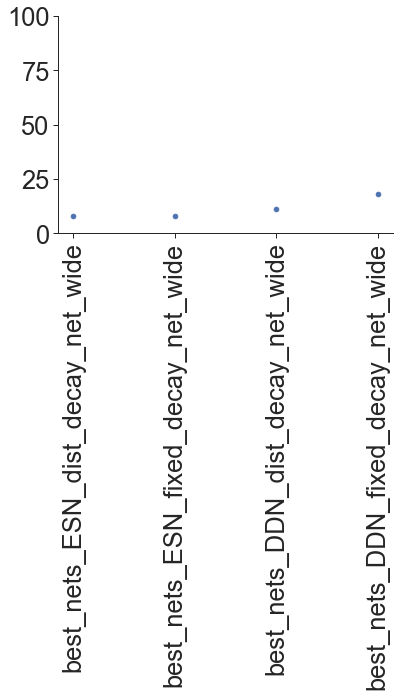

In [24]:
labels = ['best_nets_ESN_dist_decay_net_wide',
          'best_nets_ESN_fixed_decay_net_wide',
          'best_nets_DDN_dist_decay_net_wide',
          'best_nets_DDN_fixed_decay_net_wide',
          ]

plt.scatter(labels, dimensionality)
plt.xticks(rotation=90)
plt.ylim([0, 100])
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/dimensionality_ESN_DDN_NARMA.pdf', bbox_inches='tight',dpi=200)
plt.show()

In [28]:
dimensionality

[8, 8, 11, 18]

In [31]:
vals = [min(val_score_ESN_dist_decay_net_wide_dict),
# min(val_score_ESN_dist_decay_per_cluster_dict),
min(val_score_ESN_fixed_decay_net_wide_dict),
# min(val_score_ESN_fixed_decay_per_cluster_dict),
min(val_score_DDN_dist_decay_net_wide_dict),
min(val_score_DDN_fixed_decay_net_wide_dict),
# min(val_score_DDN_dist_decay_per_cluster_dict),
# min(val_score_DDN_fixed_decay_per_cluster_dict),
]

In [32]:
import pandas as pd
data_dimensionality = pd.DataFrame(data={'labels':labels, 'dimensionality':dimensionality, 'NARMA30 Score':vals})

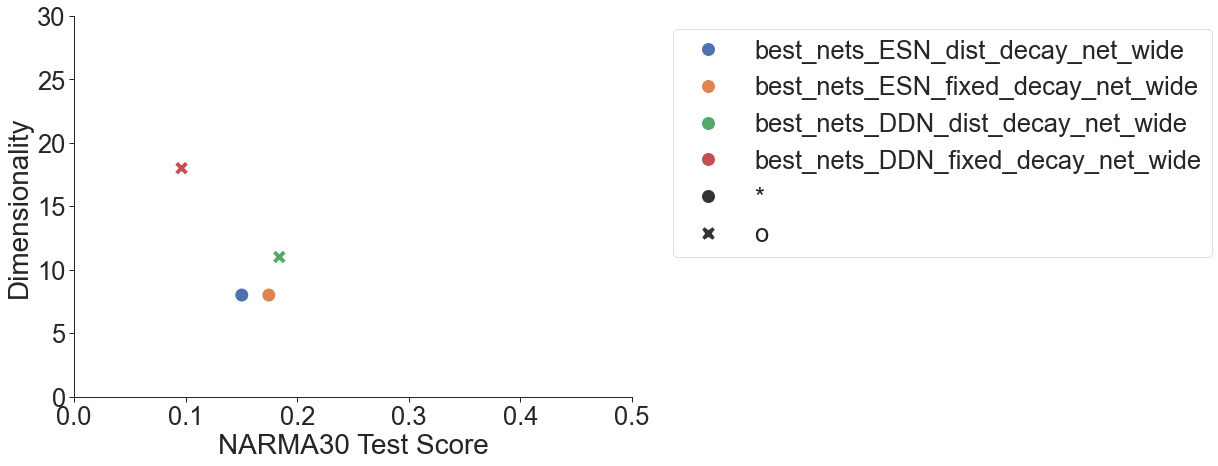

In [41]:
plt.figure(figsize=[10,7])
sns.scatterplot(data=data_dimensionality, x='NARMA30 Score', y='dimensionality', hue='labels', s=200,style=['o' if 'DDN' in i else '*' for i in labels],)
plt.xlabel('NARMA30 Test Score')
plt.ylabel('Dimensionality')
plt.ylim([0, 30])
plt.xlim([0.0, 0.5])   
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/dimensionality_vs_NARMA30_score.pdf', bbox_inches='tight',dpi=200)
plt.show()


In [42]:
data_dimensionality

,labels,dimensionality,NARMA30 Score
0,best_nets_ESN_dist_decay_net_wide,8,0.150353
1,best_nets_ESN_fixed_decay_net_wide,8,0.174596
2,best_nets_DDN_dist_decay_net_wide,11,0.183952
3,best_nets_DDN_fixed_decay_net_wide,18,0.096359


## Plot Lyapunov results 

In [43]:
with open('G:/My Drive/Data For Publication/paper3/pert_1e-9_single_vals.pkl', 'rb') as file:
    data_1e9 = pkl.load(file)
with open('G:/My Drive/Data For Publication/paper3/pert_1e-7_single_vals.pkl', 'rb') as file:
    data_1e7 = pkl.load(file)
with open('G:/My Drive/Data For Publication/paper3/pert_1e-5_single_vals.pkl', 'rb') as file:
    data_1e5 = pkl.load(file)
with open('G:/My Drive/Data For Publication/paper3/pert_1e-3_single_vals.pkl', 'rb') as file:
    data_1e3 = pkl.load(file) 
with open('G:/My Drive/Data For Publication/paper3/pert_1e-1_single_vals.pkl', 'rb') as file:
    data_1e1 = pkl.load(file)            

In [44]:
def plot_lyapunov_exp(data, model_name = '', sample_id = 0, title = False, plot_size = (10, 7)):
    fig,ax = plt.subplots(figsize=[14,6])

    ax.plot(data[0][0][0] ,linestyle='-',label='ESN_dist_decay_net_wide')
    ax.plot(data[2][0][0] ,linestyle='-',label='ESN_fixed_decay_net_wide')
    ax.plot(data[4][0][0] ,linestyle='--',label='DDN_dist_decay_net_wide')
    ax.plot(data[5][0][0] ,linestyle='--',label='DDN_fixed_decay_net_wide')
    plt.legend()

def plot_distance(data, model_name = '', sample_id = 0, title = False, plot_size = (10, 7)):
    fig,ax = plt.subplots(figsize=[14,6])

    ax.plot(data[0][1][0] , linestyle = '-' , label='ESN_dist_decay_net_wide')
    ax.plot(data[2][1][0] , linestyle = '-' , label='ESN_fixed_decay_net_wide')
    ax.plot(data[4][1][0] , linestyle = '--', label='DDN_dist_decay_net_wide')
    ax.plot(data[5][1][0] , linestyle = '--', label='DDN_fixed_decay_net_wide')

    # plt.yscale('log')   
    plt.legend()    

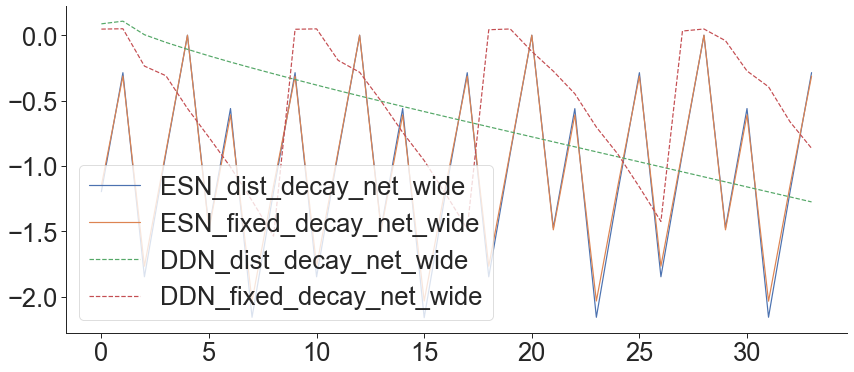

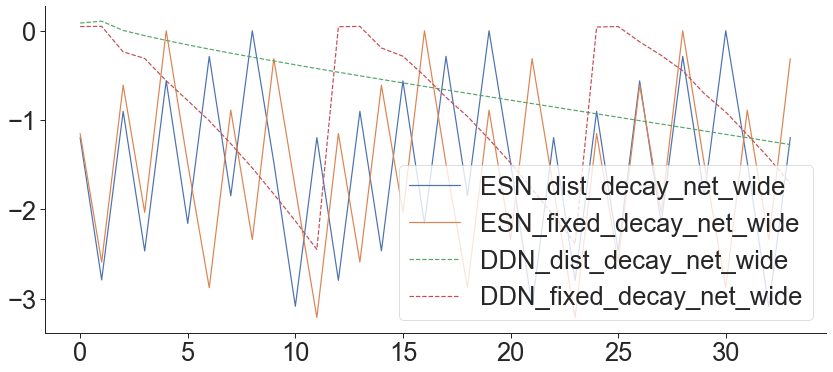

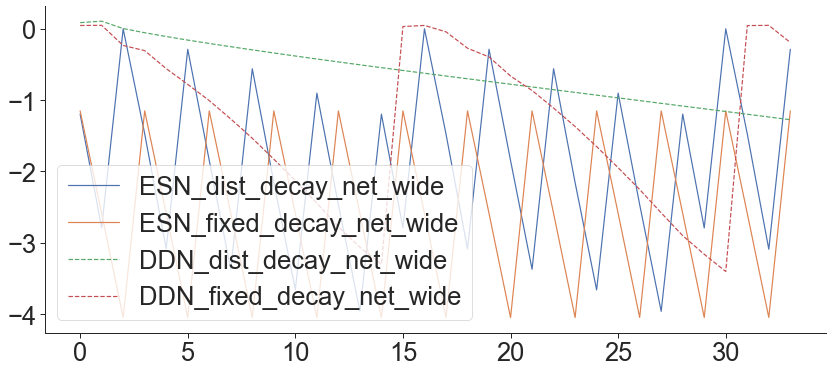

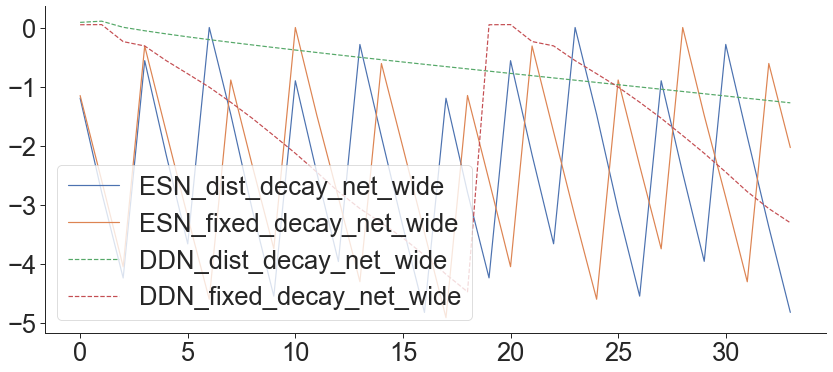

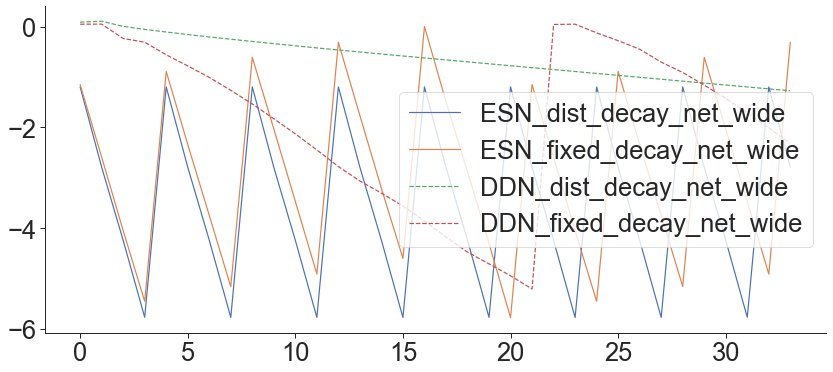

In [45]:
plot_lyapunov_exp(data_1e9)
plot_lyapunov_exp(data_1e7)
plot_lyapunov_exp(data_1e5)
plot_lyapunov_exp(data_1e3)
plot_lyapunov_exp(data_1e1)

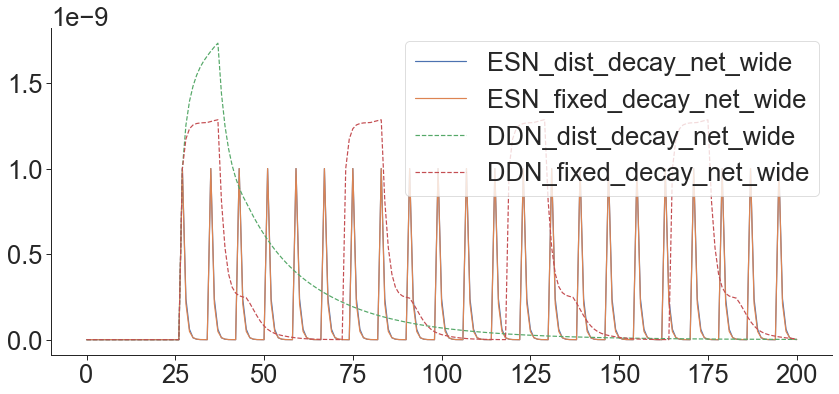

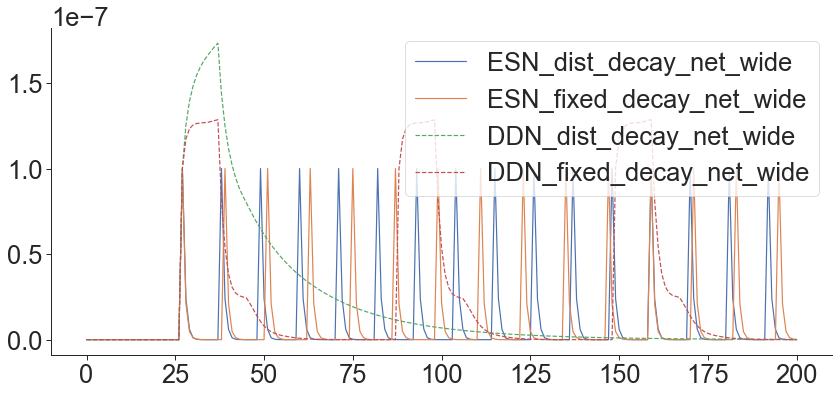

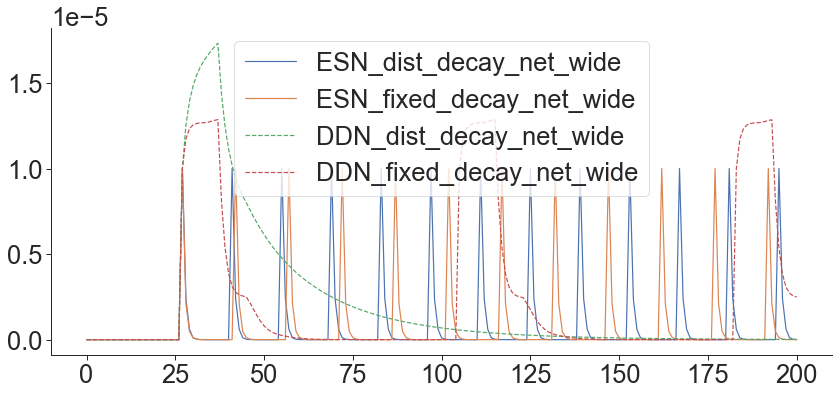

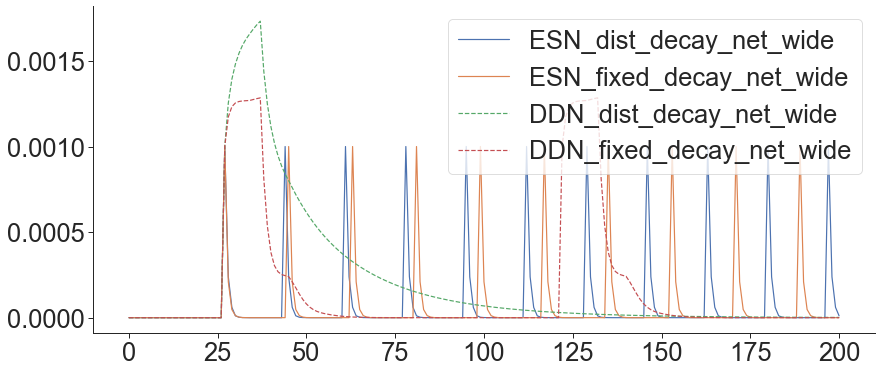

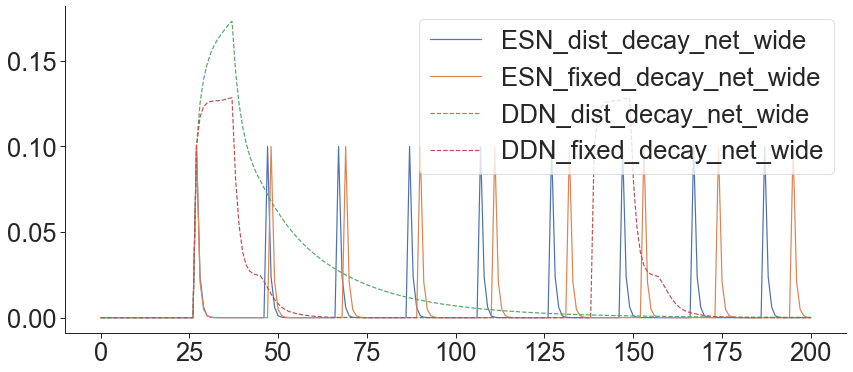

In [46]:
plot_distance(data_1e9)
plot_distance(data_1e7)
plot_distance(data_1e5)
plot_distance(data_1e3)
plot_distance(data_1e1)

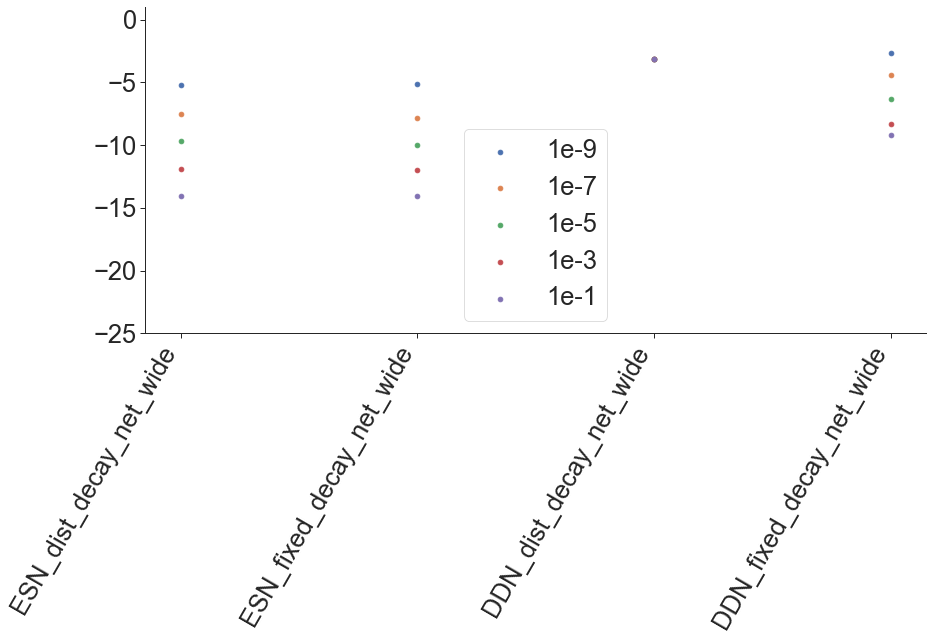

In [49]:
def cal_exp(data,pert):
    return [np.mean(np.log((np.array(data[i][1][0][27:])/pert))) for i in range(len(data))]

exps = [np.array(cal_exp(data_1e9,1e-9))[[0,2,4,5]],
        np.array(cal_exp(data_1e7,1e-7))[[0,2,4,5]], 
        np.array(cal_exp(data_1e5,1e-5))[[0,2,4,5]], 
        np.array(cal_exp(data_1e3,1e-3))[[0,2,4,5]], 
        np.array(cal_exp(data_1e1,1e-1))[[0,2,4,5]]]

nets = ['ESN_dist_decay_net_wide',
'ESN_fixed_decay_net_wide',
'DDN_dist_decay_net_wide',
'DDN_fixed_decay_net_wide',
]


fig,ax = plt.subplots(figsize=[14,6])
ax.scatter(nets,exps[0])
ax.scatter(nets,exps[1])
ax.scatter(nets,exps[2])
ax.scatter(nets,exps[3])
ax.scatter(nets,exps[4])
ax.set_xticks(nets)
ax.set_xticklabels(nets, rotation=60, ha='right')
plt.legend(['1e-9','1e-7','1e-5','1e-3','1e-1'])
plt.ylim([-25,1])
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/lyapunov_exponents_ESN_DDN_NARMA.pdf', bbox_inches='tight',dpi=200)
plt.show()
# ax.set_xticks(nets,{'rotation':45})


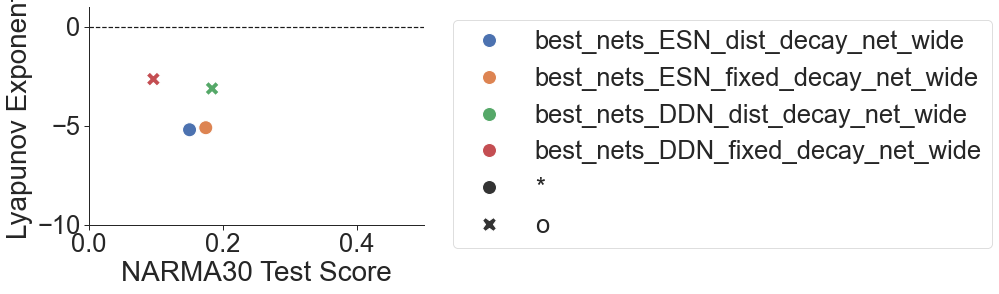

In [52]:
data_lyapunov = pd.DataFrame(data={'labels':labels, 'lyapunov_exponent':exps[0], 'val_score':vals})
sns.scatterplot(data=data_lyapunov, x='val_score', y='lyapunov_exponent', hue='labels', s=200,style=['o' if 'DDN' in i else '*' for i in labels])
plt.xlabel('NARMA30 Test Score')
plt.ylabel('Lyapunov Exponent')
plt.ylim([-10,1])
plt.xlim([0.0, 0.5])
plt.hlines(0,0.0,0.5, color='k', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/lyapunov_exponent_vs_NARMA30_score.pdf', bbox_inches='tight',dpi=200)   
plt.show()

In [53]:
data_lyapunov

,labels,lyapunov_exponent,val_score
0,best_nets_ESN_dist_decay_net_wide,-5.206903,0.150353
1,best_nets_ESN_fixed_decay_net_wide,-5.103557,0.174596
2,best_nets_DDN_dist_decay_net_wide,-3.118707,0.183952
3,best_nets_DDN_fixed_decay_net_wide,-2.644886,0.096359
